In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch
from datetime import datetime
import yaml

In [4]:
control_key = "is_control"
condition_keys = "cytokine"
condition_rep_keys = "condition_embeddings"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data_origin = "PBMC_donor11_hvg_42_0.2_True_X_pca_scaled_100_True"  #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca_scaled"
donor_rep_keys = "donor_one_hot"

In [6]:
preprocess_save_path = f"./data/processed/{data_origin}"
adata_control = sc.read_h5ad(f"{preprocess_save_path}_control.h5ad",backed='r')
adata_train = sc.read_h5ad(f"{preprocess_save_path}_train.h5ad",backed='r')
if os.path.exists(f"{preprocess_save_path}_test.h5ad"):
    adata_test = sc.read_h5ad(f"{preprocess_save_path}_test.h5ad",backed='r')
else:
    adata_test = None
# print(adata_control)
# print(adata_train)
# print(adata_test)

In [7]:
adata_control.obs[donor_rep_keys].value_counts()

donor_one_hot
11    43955
Name: count, dtype: int64

## training

In [8]:
from src.training import pre_compute_wfr_ot, seed_everything
from src.training import FNet,train
from torch.optim.lr_scheduler import CosineAnnealingLR

In [9]:
delta = 10
reg_m = 1
use_mini_batch_uot = False
group_number = 10
ot_origin = f"delta{delta}_regm{reg_m}"
save_path_train = f"./experiments/ot_plan/ot_precompute_{data_origin}_{ot_origin}_train.pkl"
save_path_test = f"./experiments/ot_plan/ot_precompute_{data_origin}_{ot_origin}_test.pkl"

load_saved = True
if os.path.exists(save_path_train) and load_saved:
    print(f"read{save_path_train}")
    ot_results_train = pd.read_pickle(save_path_train)
else:
    ot_results_train = pre_compute_wfr_ot(adata_control, 
                           adata_train, 
                           save_path_train, 
                           sample_rep=sample_rep, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw = False)

if os.path.exists(save_path_test) and load_saved:
    print(f"read{save_path_test}")
    ot_results_test = pd.read_pickle(save_path_test)
else:
    ot_results_test = pre_compute_wfr_ot(adata_control, 
                           adata_test, 
                           save_path_test, 
                           sample_rep=sample_rep, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw=False)


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/utils.py:156: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_indices = adata_treated.obs.groupby(condition_keys).indices
100%|██████████| 10/10 [04:09<00:00, 24.93s/it]


Batch saved: 10/72


100%|██████████| 10/10 [03:52<00:00, 23.28s/it]


Batch saved: 20/72


100%|██████████| 10/10 [03:44<00:00, 22.47s/it]


...

Batch saved: 72/72
合并所有batch...
完成！最终结果: ./experiments/ot_plan/ot_precompute_PBMC_donor11_hvg_42_0.2_True_X_pca_scaled_100_True_delta10_regm1_train.pkl


100%|██████████| 10/10 [03:54<00:00, 23.46s/it]


Batch saved: 10/18


100%|██████████| 8/8 [03:04<00:00, 23.04s/it]


Batch saved: 18/18
合并所有batch...
完成！最终结果: ./experiments/ot_plan/ot_precompute_PBMC_donor11_hvg_42_0.2_True_X_pca_scaled_100_True_delta10_regm1_test.pkl


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

n_iterations = 20000

load_experiment = False # 如果是False可以无视下面三个参数
experiment_load_path = "experiments/exp_20260224_155124_PBMC_donor11_hvg_42_0.4_False_X_pca_scaled_100_False_delta10_regm1"
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_11_epoch_20000.pt") 

if not load_experiment:
    experiment_save_path = os.path.join("experiments", f"exp_{timestamp}_{data_origin}_{ot_origin}")
    checkpoint_save_path = os.path.join(experiment_save_path, "checkpoints")
    os.makedirs(checkpoint_save_path, exist_ok=True)
    
    config = {
        "in_out_dim": adata_control.obsm[sample_rep].shape[1],
        "condition_dim": adata_train.obsm[condition_rep_keys].shape[1],
        
        "hidden_dim_v": 4096,   
        "hidden_dim_g": 1024,
        "n_hiddens_v": 4,
        "n_hiddens_g": 2,
    
        "con_embedding_dim": 512,
        "hidden_dim_con": 1024,
        
        "time_dim": 1024,
        "time_embedding_dim": 256,
        "hidden_dim_time": 512,

        "num_donor": 12,
        "contain_donor": True, # 额外的输入donor标签作为condition one-hot编码
        "donor_emb_dim": 128,
        
        "bottle_dim": 1024,
        "activation": 'SiLU',
        
        "batch_size_per_condition": 256,  
        "batch_size_condition":10,
        "learning_rate": 5e-5,  
        "weight_decay":1e-4,
        "eta_min":5e-6,
        "seed": 42,
        "eval_interval":10,
    }
    config_save_path = f"{experiment_save_path}/config.yaml"
    with open(config_save_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
        print(f"config saved to {config_save_path}")
else:
    with open(config_load_path, 'r') as f:
        config = yaml.safe_load(f)
        print(f"load saved_config from {config_load_path}")

    experiment_save_path = experiment_load_path  #直接继续某一个实验
    checkpoint_save_path = os.path.join(experiment_save_path, "checkpoints")


model = FNet(config["in_out_dim"], config["hidden_dim_v"], config["n_hiddens_v"], config["hidden_dim_g"], config["n_hiddens_g"], 
             config["condition_dim"], config["con_embedding_dim"], config["hidden_dim_con"], 
             config["time_dim"] ,config["time_embedding_dim"],config["hidden_dim_time"], 
             config["bottle_dim"], config["num_donor"], config["donor_emb_dim"], config["contain_donor"],config["activation"])

model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=n_iterations, eta_min=config["eta_min"])
seed_everything(config["seed"])

if load_experiment:    
    if os.path.exists(model_load_path):
        checkpoint = torch.load(model_load_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print(f"load model from {model_load_path}")
    else:
        print("wrong model_load_path")

print("setup complete")

cuda
config saved to experiments/exp_20260226_145002_PBMC_donor11_hvg_42_0.2_True_X_pca_scaled_100_True_delta10_regm1/config.yaml
Global seed set to 42
setup complete


In [11]:
model_save_path = os.path.join(checkpoint_save_path, "test_11")
train.train_model(adata_control, adata_train, adata_test,
                ot_results_train, ot_results_test, 
                model.to(device),
                optimizer,
                scheduler = scheduler,
                n_iterations= n_iterations,
                batch_size_per_condition = config["batch_size_per_condition"],
                batch_size_condition = config["batch_size_condition"],
                sample_rep = sample_rep,
                condition_keys=condition_keys,
                condition_rep_keys = condition_rep_keys,
                donor_rep_keys = donor_rep_keys,
                device = device,
                save_path=model_save_path,
                eval_interval = config["eval_interval"],
                save_interval = 5000, #每隔多少轮保存一次
                save_only_last = False) # 是否只保留最后的pt文件


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/data.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices
/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/data.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices


data_loaded
data_loaded


Begin flow and growth matching...:   3%|▎         | 611/20000 [19:59<10:34:16,  1.96s/epoch, loss=0.137, vloss=0.135, gloss=0.002, test_loss=0.184, test_vloss=0.147, test_gloss=0.038]


KeyboardInterrupt: 

In [6]:
model_save_path = "experiments/exp_20260219_213059_PBMC_donor11_hvg_42_0.4_False_X_pca_scaled_100_delta10_regm1/checkpoints/test"

训练步数: 9900
最后一步 Loss: 0.654389
最后一步 vLoss: 0.646324
最后一步 gLoss: 0.008065
最后一步 test_Loss: 0.738688
最后一步 test_vLoss: 0.687185
最后一步 test_gLoss: 0.051503


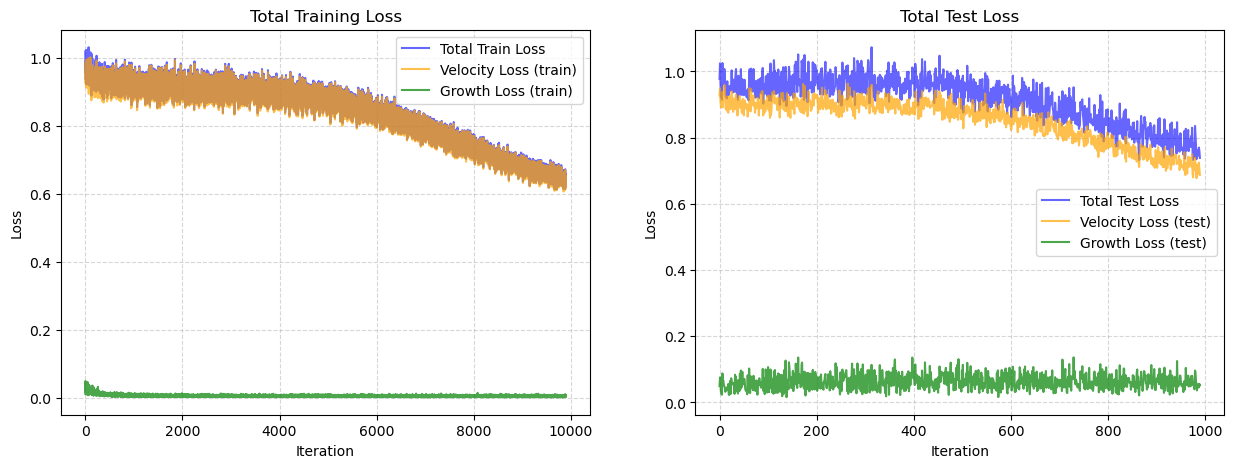

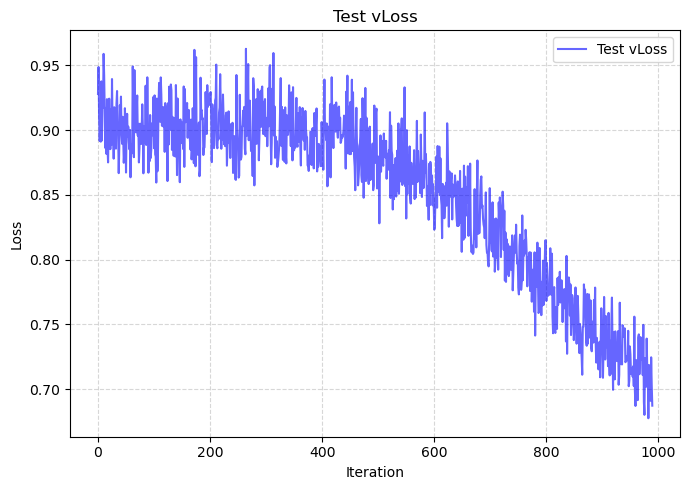

In [12]:
from src.evaluate import draw_loss
load_path = f"{model_save_path}_epoch_10000.pt"
draw_loss(load_path,eval_interval = 10,cut = 100,save_path = None) # cut代表去掉前多少个epoch 避免前期loss过大影响观察